In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import os
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, classification_report, silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

In [2]:
customers = pd.read_excel('../data/Online Retail.xlsx')

In [3]:
customers.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
502303,578844,22163,HEART STRING MEMO HOLDER HANGING,1,2011-11-25 16:14:00,1.63,NaN,United Kingdom
533289,581023,21155,RED RETROSPOT PEG BAG,5,2011-12-07 10:35:00,4.96,NaN,United Kingdom
318629,564837,23089,GLASS BON BON JAR,4,2011-08-30 12:40:00,3.29,NaN,United Kingdom
527473,580720,85227,SET OF 6 3D KIT CARDS FOR KIDS,1,2011-12-05 16:55:00,0.85,14629.0,United Kingdom
435676,574076,22593,CHRISTMAS GINGHAM STAR,1,2011-11-02 15:38:00,1.63,NaN,United Kingdom


In [4]:
customers.shape

(541909, 8)

In [5]:
customers.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


Quantity and unitprice have negative numbers which is impossible

In [6]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [7]:
customers.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
customers['Description'].isna().sum()/len(customers)*100

np.float64(0.2683107311375157)

In [9]:
print(f'The Percentage of CUSTOMERID missing values is: {(customers['CustomerID'].isna().sum()/len(customers)*100):.1f}%')

The Percentage of CUSTOMERID missing values is: 24.9%


In [10]:
customers['CustomerID']=customers.CustomerID.dropna()

In [11]:
customers['Description'] = customers.Description.fillna(customers['StockCode'])

Descripion adn CustomerID have missing values and customerID has significant amount how ever it doesn't seem to me that we need the id in the first place

In [12]:
print(f'The Percentage of CUSTOMERID missing values is: {(customers.duplicated().sum()/len(customers)*100):.2f}%')

The Percentage of CUSTOMERID missing values is: 0.97%


In [13]:
print(customers.duplicated().sum())
customers = customers.drop_duplicates(keep='first')
customers.shape

5268


(536641, 8)

Now let's investigate why quantity and unitprice have negative values

In [14]:
# customers = customers[customers['Quantity']>=0]
# customers = customers[customers['UnitPrice']>=0]
# customers.shape

In [15]:
weird_negative_values = customers[(customers['Quantity']<0)]
print(weird_negative_values.shape)
weird_negative_values.InvoiceNo.str.startswith('C').value_counts()

(10587, 8)


InvoiceNo
True    9251
Name: count, dtype: int64

okay now we see that when the invoice number starts with c its quantity is <0

In [16]:
weird_negative_values = customers[(customers['UnitPrice']<0)]
weird_negative_values

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


we see that the negative values in price are bad debts, so we remove them

In [17]:
customers = customers[customers['UnitPrice']>=0]

Univariate Analysis

Categorical features: country, description,stockcode

In [18]:
len(customers.Country.unique())

38

In [19]:
customers.Country.value_counts().sort_values(ascending=False)

Country
United Kingdom          490298
Germany                   9480
France                    8541
EIRE                      8184
Spain                     2528
Netherlands               2371
Belgium                   2069
Switzerland               1994
Portugal                  1510
Australia                 1258
Norway                    1086
Italy                      803
Channel Islands            757
Finland                    695
Cyprus                     611
Sweden                     461
Unspecified                442
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     294
USA                        291
Hong Kong                  284
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


if we have time we'll do it by continents

In [20]:
customers.Description.value_counts().sort_values(ascending=False)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2357
REGENCY CAKESTAND 3 TIER              2189
JUMBO BAG RED RETROSPOT               2156
PARTY BUNTING                         1720
LUNCH BAG RED RETROSPOT               1625
                                      ... 
23406                                    1
????damages????                          1
21620                                    1
lost                                     1
85175                                    1
Name: count, Length: 5182, dtype: int64

In [21]:
customers.StockCode.value_counts().sort_values(ascending=False)

StockCode
85123A    2301
22423     2192
85099B    2156
47566     1720
20725     1626
          ... 
23609        1
85179a       1
23617        1
90214U       1
47591b       1
Name: count, Length: 4070, dtype: int64

In [22]:
# plt.figure(figsize=(6,4))
# sns.barplot(customers['StockCode'])
# plt.show()

Numerical Values

In [23]:
customers.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,536639.000000,536639,536639.000000,401604.000000
mean,9.620061,2011-07-04 08:56:53.450009,4.673900,15281.160818
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,1.000000,2011-03-28 10:52:00,1.250000,13939.000000
50%,3.000000,2011-07-19 14:04:00,2.080000,15145.000000
75%,10.000000,2011-10-18 17:05:00,4.130000,16784.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,219.130564,NaN,94.857114,1714.006089


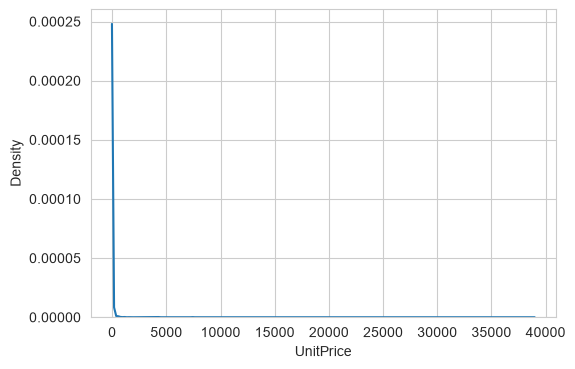

In [24]:
plt.figure(figsize=(6,4))
sns.kdeplot(customers['UnitPrice'])
plt.show()

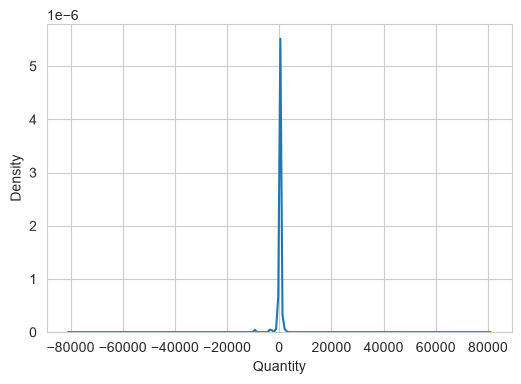

In [25]:
plt.figure(figsize=(6,4))
sns.kdeplot(customers['Quantity'])
plt.show()

In [26]:
customers['InvoiceDate'] = pd.to_datetime(customers['InvoiceDate'])
customers['Months'] = customers.InvoiceDate.dt.month
customers['Months'].value_counts().sort_values(ascending=False)

Months
11    83343
12    67227
10    59969
9     49861
7     39267
5     36782
6     36609
3     36439
8     35062
1     34900
4     29701
2     27479
Name: count, dtype: int64

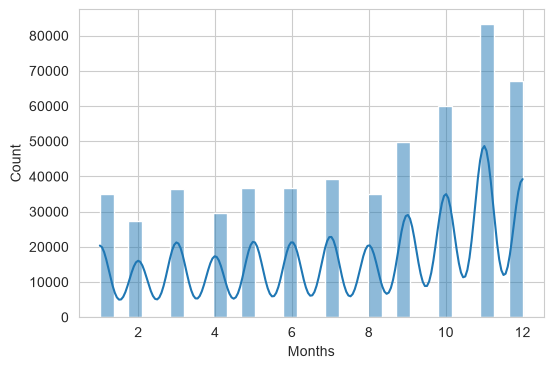

In [27]:
plt.figure(figsize=(6,4))
sns.histplot(data=customers,x='Months',bins=30,kde=True)
plt.show()

In [28]:
customers['InvoiceDate'] = pd.to_datetime(customers['InvoiceDate'])
customers['Hours'] = customers.InvoiceDate.dt.hour
customers['Hours'].value_counts().sort_values(ascending=False)

Hours
12    77573
15    76938
13    71247
14    66570
11    56949
16    54134
10    48808
9     34314
17    28371
8      8906
18     7941
19     3617
20      847
7       383
6        41
Name: count, dtype: int64

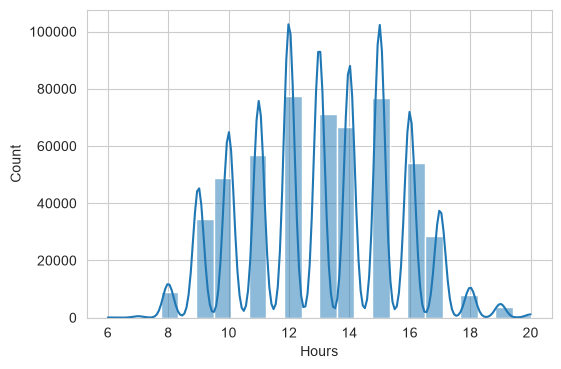

In [29]:
plt.figure(figsize=(6,4))
sns.histplot(data=customers, x='Hours', bins=24, kde=True)
plt.show()

Bivariate and Multivariate Analysis

In [30]:
(customers.groupby('Description')['StockCode'].nunique().sort_values(ascending=False))

Description
check                146
?                     47
damages               43
damaged               43
found                 25
                    ... 
15030                  1
10134                  1
10080                  1
10002                  1
wrongly sold sets      1
Name: StockCode, Length: 5182, dtype: int64

In [31]:
(customers.groupby('StockCode')['Description'].nunique().sort_values(ascending=False))

StockCode
20713     9
23084     8
21830     7
85175     7
23131     6
         ..
22189     1
16016     1
22190     1
22191     1
84970L    1
Name: Description, Length: 4070, dtype: int64

In [32]:
customers[customers['StockCode']==20713]['Description'].unique()

array(['JUMBO BAG OWLS', 20713, 'wrongly marked. 23343 in box',
       'wrongly coded-23343', 'found', 'Found', 'wrongly marked 23343',
       'Marked as 23343', 'wrongly coded 23343'], dtype=object)

In [33]:
customers[customers['Description']=='check']['StockCode']

13217     84968F
13218     84968E
108577    84249A
113580     84598
381676    90195A
           ...  
535325     23404
535331    72801C
535333     23395
535334     22142
535336     22576
Name: StockCode, Length: 159, dtype: object

So now let's do RFM:Recency, frequency, and monetory

In [34]:
customers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Months,Hours
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,8


In [35]:
import datetime as dt
customers['TotalSpend'] = customers['Quantity']*customers['UnitPrice']
snapshot_date = customers.InvoiceDate.max() + dt.timedelta(days=1)
customers['InvoiceNo']
RFM = customers.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalSpend': 'sum',
}).reset_index()
RFM.rename(columns={
    'InvoiceDate':'Recency',
    'InvoiceNo':'Frequency',
    'TotalSpend':'Monetory'
    },inplace=True)

In [36]:
RFM.head()

,CustomerID,Recency,Frequency,Monetory
0,12346.0,326,2,0.00
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [37]:
RFM.skew()



CustomerID     0.000918
Recency        1.249665
Frequency     11.412274
Monetory      21.704784
dtype: float64

The Data is Highly skewed


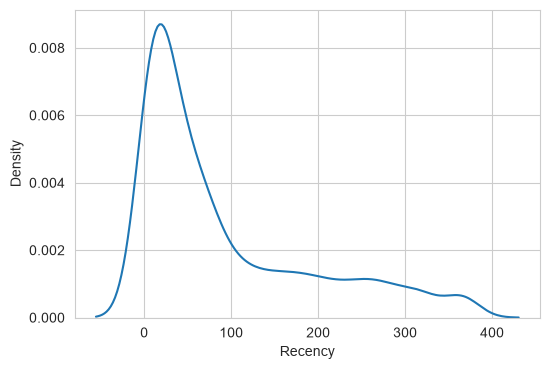

In [38]:
plt.figure(figsize=(6,4))
sns.kdeplot(RFM.Recency)
plt.show()

In [39]:
RFM.set_index('CustomerID')
RFM = RFM[RFM['Monetory']>0]
RFM_log = np.log1p(RFM)
RFM_log['Frequency'] = np.log1p(RFM_log['Frequency'])
RFM_log.skew()


CustomerID   -0.134967
Recency      -0.357025
Frequency     0.466224
Monetory      0.215732
dtype: float64

In [40]:
X_train, X_test = train_test_split(RFM_log,random_state=42,test_size=0.2)

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

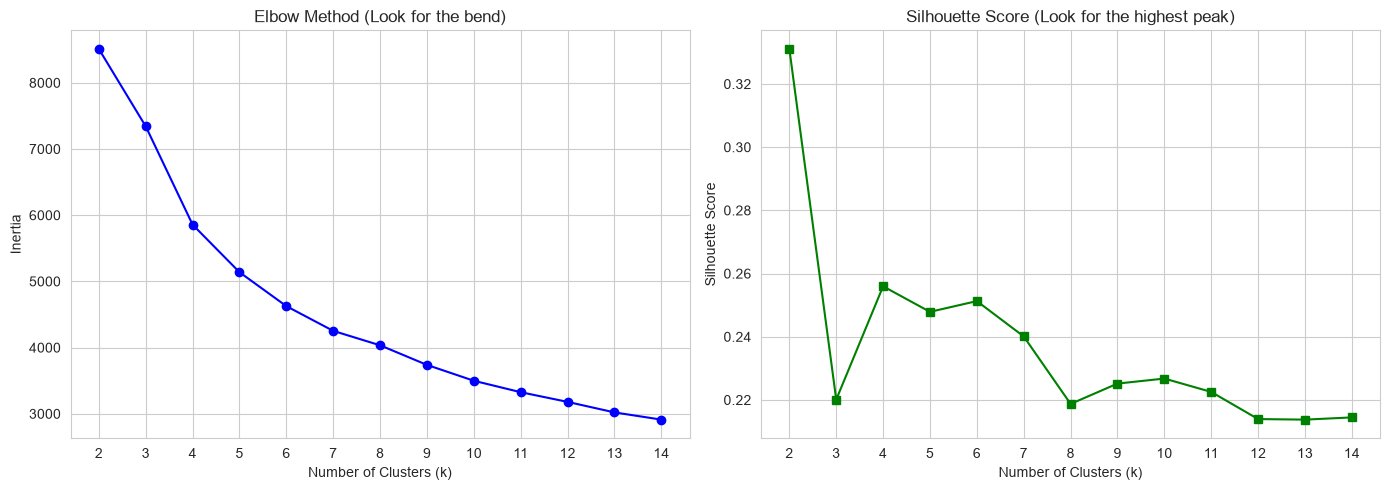

In [42]:
silhoute_values=[]
_inertia_values = []
k_range = range(2,15)
for k in k_range:
    model = KMeans(n_clusters=k,n_init='auto',random_state=42)
    model.fit(X_train_scaled)
    _inertia_values.append(model.inertia_)
    score = silhouette_score(X_train_scaled,model.labels_)
    silhoute_values.append(score)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Elbow Method (Inertia)
ax1.plot(k_range, _inertia_values, marker='o', color='blue')
ax1.set_title('Elbow Method (Look for the bend)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(k_range)

# Plot 2: Silhouette Score
ax2.plot(k_range,silhoute_values, marker='s', color='green')
ax2.set_title('Silhouette Score (Look for the highest peak)')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_range)

plt.tight_layout()
plt.show()

In [43]:
optimal_k = 4
Bestmodel = KMeans(n_clusters=optimal_k,random_state=42,n_init='auto')

train_clusters = Bestmodel.fit_predict(X_train_scaled)
test_clusters = Bestmodel.predict(X_test_scaled)

training_score = silhouette_score(X_train_scaled,train_clusters)
testing_score = silhouette_score(x_test_scaled,test_clusters)
print(f"Train Silhouette Score: {training_score:.3f}")
print(f"Test Silhouette Score: {testing_score:.3f}")

NameError: name 'x_test_scaled' is not defined

In [ ]:
RFM_scaled = scaler.transform(RFM_log)
cluster_list = Bestmodel.predict(RFM_scaled)
RFM['clusters'] = cluster_list
RFM.sample(5)

,CustomerID,Recency,Frequency,Monetory,clusters
1101,13823.0,19,2,957.66,3
422,12878.0,18,3,841.64,3
1897,14913.0,36,4,1227.43,0
1694,14636.0,36,2,609.85,3
2974,16367.0,37,2,800.67,0


In [ ]:
RFM_group = RFM.groupby('clusters').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetory':['mean','count']
    })
RFM_group.columns=['AVgRecency (days)','AvgFrequency','AvgMonetory','Customer_count']
RFM_group.head()

,AVgRecency (days),AvgFrequency,AvgMonetory,Customer_count
clusters,,,,
0,42.184944,5.680297,1582.732705,1076
1,17.469838,13.719258,6363.641311,862
2,156.949196,1.469094,323.496826,1181
3,120.247714,2.025769,599.517549,1203


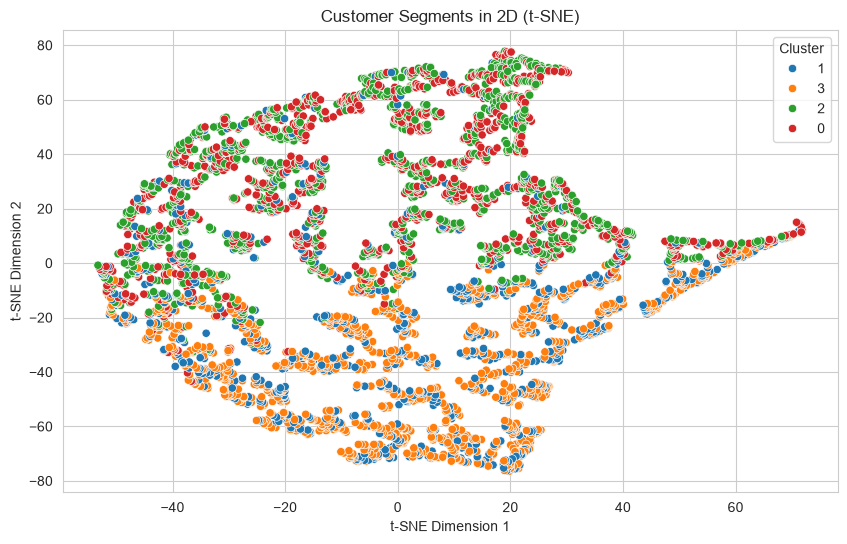

In [ ]:
from sklearn.manifold import TSNE

tsne1 = TSNE(n_components=2)
tsnedata_features = tsne1.fit_transform(RFM)
tsnedata = pd.DataFrame(tsnedata_features,columns=['dim1','dim2'])
tsnedata['clusters'] = RFM.clusters.astype('str')

plt.figure(figsize=(10,6))
sns.scatterplot(data=tsnedata, x='dim1',y='dim2',hue='clusters')
plt.title('Customer Segments in 2D (t-SNE)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster')
plt.show()
plt.show()